# AchromatCFW demo

This notebook demonstrates basic usage of the core functions in `scr.chromf.cfw`.

In [1]:
# ───────────────────────────── Imports ─────────────────────────────
import sys
from pathlib import Path
from typing import Literal

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, FloatSlider, Checkbox

# Allow "import chromf …" without installing the package
sys.path.insert(0, str(Path("..").resolve() / "src"))

from chromf.spectrum_loader import _load_defocus, _load_daylight, _load_sensor, channel_products
from chromf.optiland_bridge import compute_chl_curve
from chromf.cfw import (
    edge_rgb_response,
    detect_fringe_binary,
    fringe_width,
)

In [2]:
# ── Optical system definition ────────────────────────────────────────────────
# Air-spaced achromatic doublet — f ≈ 50 mm, f/2  (EPD = 25 mm)
# Crown : N-BK7  (n_d = 1.5168, V_d ≈ 64.2)
# Flint : N-SF5  (n_d = 1.6727, V_d ≈ 32.2)
#
# The lens is well corrected for primary chromatic aberration (CHL ≈ 0 at
# F and C lines); secondary spectrum is ~117 µm.  At f/2 the PSF blur from
# this residual CHL is large enough to produce clearly visible colour fringes,
# demonstrating that good LCA correction ≠ good fringe performance.

from optiland import optic as op

optic = op.Optic()
optic.add_surface(index=0, radius=np.inf,   thickness=np.inf)                              # object at ∞
optic.add_surface(index=1, radius=26.0,     thickness=4.0,  material='N-BK7', is_stop=True)  # crown front
optic.add_surface(index=2, radius=-26.0,    thickness=0.1)                                  # crown rear / air gap
optic.add_surface(index=3, radius=-26.0,    thickness=2.5,  material='N-SF5')               # flint front
optic.add_surface(index=4, radius=-113.0,   thickness=42.0)                                 # flint rear / BFD
optic.add_surface(index=5, radius=np.inf,   thickness=0.0)                                  # image plane

optic.add_wavelength(value=0.55, is_primary=True)   # 550 nm reference (µm)
optic.set_aperture(aperture_type='EPD', value=25.0)  # f/2 — large aperture to amplify fringe effect
optic.set_field_type(field_type='angle')
optic.add_field(y=0.0)

In [3]:
# ──────────────────────────── Data load ────────────────────────────
prods = channel_products()
sensor_wl = prods["blue"][:, 0]   # nm — must match SENSOR_RESPONSE in cfw.py

if optic is not None:
    focal_shift_curve = compute_chl_curve(optic, wavelengths_nm=sensor_wl)
    FN_DEFAULT = float(optic.paraxial.FNO())
else:
    focal_shift_curve = _load_defocus()
    FN_DEFAULT = 1.4                             # default: f/1.4

wl      = focal_shift_curve[:, 0]
chl_um  = focal_shift_curve[:, 1]               # CHL in µm

sensor_map = {"R": prods["red"][:, 1],
              "G": prods["green"][:, 1],
              "B": prods["blue"][:, 1]}

# ──────────────────────────── Display constants ─────────────────────
GAMMA_DEFAULT    = 2.2        # display gamma
EXPOSURE_DEFAULT = 8.0        # tanh-curve slope
XRANGE           = 100        # half-width of x-scan window (µm)
DEFOCUS_RANGE    = 300        # ±z sweep (µm)
DEFOCUS_STEP     = 5         # slider step (µm)
X_RES_P1   = 2               # Plot 1 sampling step (µm)
X_RES_P2   = 1               # Plot 2 sampling step (µm)
IMG_HEIGHT = 60              # Plot 2 image height (px)

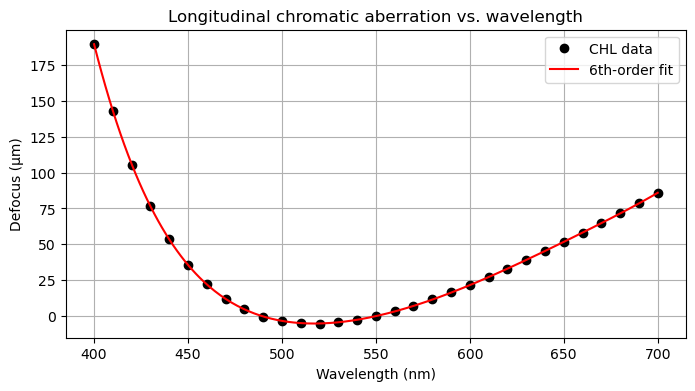

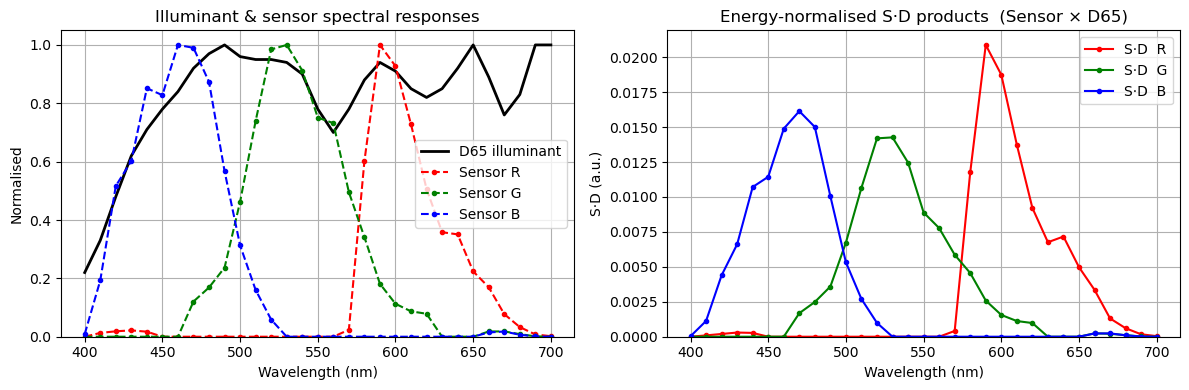

In [4]:
# ───────────────────── Optional diagnostic plots ───────────────────
# --- 1. CHL curve and 6th-order fit --------------------------------
coeffs = np.polyfit(wl, chl_um, 6)
wl_fit = np.linspace(wl.min(), wl.max(), 300)
chl_fit = np.polyval(coeffs, wl_fit)

plt.figure(figsize=(8, 4))
plt.plot(wl,      chl_um,  "o", color="k",   label="CHL data")
plt.plot(wl_fit,  chl_fit, "-", color="red", label="6th-order fit")
plt.title("Longitudinal chromatic aberration vs. wavelength")
plt.xlabel("Wavelength (nm)");  plt.ylabel("Defocus (µm)")
plt.grid(True);  plt.legend();  plt.show()

# --- 2. Illuminant, sensor responses, and S·D products -------------
# Load raw curves and normalise each to peak = 1
_raw = {ch: _load_sensor(ch) for ch in ("red", "green", "blue")}
for v in _raw.values():
    v[:, 1] /= v[:, 1].max()

_dl      = _load_daylight()
dl_vals  = np.interp(wl, _dl[:, 0], _dl[:, 1])
dl_vals /= dl_vals.max()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left panel: D65 illuminant + raw sensor responses
ax1.plot(wl, dl_vals, color="k", lw=2, label="D65 illuminant")
for ch, col in (("red", "r"), ("green", "g"), ("blue", "b")):
    ax1.plot(_raw[ch][:, 0], _raw[ch][:, 1], "o--", color=col, ms=3,
             label=f"Sensor {ch[0].upper()}")
ax1.set_title("Illuminant & sensor spectral responses")
ax1.set_xlabel("Wavelength (nm)");  ax1.set_ylabel("Normalised")
ax1.set_ylim(0, None);  ax1.grid(True);  ax1.legend()

# Right panel: energy-normalised S·D products
for ch, col in {"R": "r", "G": "g", "B": "b"}.items():
    ax2.plot(wl, sensor_map[ch], "o-", color=col, ms=3, label=f"S·D  {ch}")
ax2.set_title("Energy-normalised S·D products  (Sensor × D65)")
ax2.set_xlabel("Wavelength (nm)");  ax2.set_ylabel("S·D (a.u.)")
ax2.set_ylim(0, None);  ax2.grid(True);  ax2.legend()

plt.tight_layout();  plt.show()

In [ ]:
# ─────────────────────── Interactive section ───────────────────────

def update_plots(
    z: float,
    gamma: float,
    exposure: float,
    psf_mode_choice: Literal["geom", "gauss"],
) -> None:
    psf_mode = psf_mode_choice

    # ---------- Plot 1: edge functions ----------
    x_vals = np.arange(-XRANGE, XRANGE + X_RES_P1, X_RES_P1, dtype=float)
    edge_rgb = np.array([
        edge_rgb_response(
            x, z,
            exposure_slope=exposure,
            gamma=gamma,
            chl_curve_um=chl_um,
            f_number=FN_DEFAULT,
            psf_mode=psf_mode,
        )
        for x in x_vals
    ])
    edge_r, edge_g, edge_b = edge_rgb.T

    boundaries = np.array([
        detect_fringe_binary(
            x, z,
            exposure_slope=exposure,
            gamma=gamma,
            chl_curve_um=chl_um,
            f_number=FN_DEFAULT,
            psf_mode=psf_mode,
        )
        for x in x_vals
    ], dtype=bool)

    fig = plt.figure(figsize=(12, 6))
    ax1 = fig.add_subplot(1, 2, 1)
    ax1.plot(x_vals, edge_r, color="r", label="R")
    ax1.plot(x_vals, edge_g, color="g", label="G")
    ax1.plot(x_vals, edge_b, color="b", label="B")

    jumps = np.flatnonzero(np.diff(boundaries.astype(int), prepend=boundaries[0]))
    if jumps.size:
        for idx in jumps:
            ax1.axvline(x_vals[idx], color="k", ls="--", lw=1,
                        label="Fringe boundary" if idx == jumps[0] else None)

    title_map = {
        "geom": "Geometric (pillbox) PSF",
        "gauss": "Gaussian PSF",
    }
    ax1.set(xlabel="x (µm)", ylabel="Normalised response",
            title=f"Edge responses — {title_map.get(psf_mode, psf_mode)}",
            ylim=(0, 1))
    ax1.legend();  ax1.grid(True)

    # ---------- Plot 2: pseudo-density map ----------
    X = np.arange(-XRANGE, XRANGE + X_RES_P2, X_RES_P2, dtype=float)
    img_row = np.array([
        edge_rgb_response(
            x, z,
            exposure_slope=exposure,
            gamma=gamma,
            chl_curve_um=chl_um,
            f_number=FN_DEFAULT,
            psf_mode=psf_mode,
        )
        for x in X
    ])
    img = np.repeat(np.clip(img_row, 0, 1)[:, None, :], IMG_HEIGHT, axis=1)

    ax2 = fig.add_subplot(1, 2, 2)
    ax2.imshow(img.swapaxes(0, 1),
               extent=[X.min(), X.max(), 0, IMG_HEIGHT],
               aspect="auto", origin="lower")
    ax2.set_xlabel("x (µm)");  ax2.set_yticks([])
    ax2.set_title("Pseudo-density fringe map")

    plt.tight_layout();  plt.show()

    width = fringe_width(
        z,
        exposure_slope=exposure,
        gamma=gamma,
        chl_curve_um=chl_um,
        f_number=FN_DEFAULT,
        psf_mode=psf_mode,
    )
    print(f"Colour-fringe width ≈ {width} µm")

# ipywidgets driver
interact(
    update_plots,
    z=FloatSlider(
        value=0, min=-DEFOCUS_RANGE, max=DEFOCUS_RANGE, step=DEFOCUS_STEP,
        description="Defocus (µm)", continuous_update=False),
    gamma=FloatSlider(
        value=GAMMA_DEFAULT, min=1.0, max=3.0, step=0.1,
        description="Gamma", continuous_update=False),
    exposure=FloatSlider(
        value=EXPOSURE_DEFAULT, min=1, max=16, step=1,
        description="Exposure", continuous_update=False),
    psf_mode_choice=widgets.Dropdown(
        options=[("Geometric", "geom"),
                 ("Gaussian", "gauss")],
        value="gauss",
        description="PSF core:",
    ),
)

interactive(children=(FloatSlider(value=0.0, continuous_update=False, description='Defocus (µm)', max=300.0, m…

<function __main__.update_plots(z: float, gamma: float, exposure: float, psf_mode_choice: Literal['geom', 'gauss']) -> None>

In [6]:
# ---------------------------------------------------------------------
# Defocus vector (z samples, µm)
# ---------------------------------------------------------------------
z_vals = np.arange(-DEFOCUS_RANGE, DEFOCUS_RANGE + DEFOCUS_STEP,
                   DEFOCUS_STEP, dtype=float)

# ---------------------------------------------------------------------
# Single-curve helper
# ---------------------------------------------------------------------
def _plot_cfw_curve(exposure: float, psf_mode: str, label: str) -> np.ndarray:
    """Compute CFW for every z, draw the curve, and return [z, CFW] samples."""
    data = np.array([
        [
            z,
            fringe_width(
                z,
                exposure_slope=exposure,
                gamma=GAMMA_DEFAULT,
                chl_curve_um=chl_um,
                f_number=FN_DEFAULT,        # ← global constant
                psf_mode=psf_mode,
            ),
        ]
        for z in z_vals
    ])
    plt.plot(data[:, 0], data[:, 1], "o-", ms=3, label=label)
    return data

# ---------------------------------------------------------------------
# Comparison plot + statistics
# ---------------------------------------------------------------------
def plot_cfw_comparison(
    exposures=(EXPOSURE_DEFAULT,),
    psf_mode: Literal["geom", "gauss"] = "gauss",
) -> None:
    """Draw a CFW-vs-z curve for each exposure value and print basic stats."""
    title_map = {
        "geom": "Geometric (pillbox) PSF",
        "gauss": "Gaussian PSF",
    }
    psf_label = title_map.get(psf_mode, psf_mode)

    plt.figure(figsize=(8, 4))
    print(f"\n=== Statistics ({psf_label}, f-number={FN_DEFAULT}) ===")
    print("Exp  max(width)   mean(width)")
    print("-" * 30)

    for exp in sorted(exposures):
        data = _plot_cfw_curve(exp, psf_mode, label=f"Exposure = {exp}")
        print(f"{exp:<4} {data[:,1].max():>10.2f}   {data[:,1].mean():>10.2f}")

    plt.title(f"Colour-fringe width vs defocus — {psf_label}")
    plt.xlabel("Defocus z (µm)")
    plt.ylabel("Colour-fringe width (µm)")
    plt.legend()
    plt.grid(True)
    plt.show()

# ---------------------------------------------------------------------
# ipywidgets driver
# ---------------------------------------------------------------------
def interactive_plot(exposures, psf_mode_choice):
    plot_cfw_comparison(exposures=exposures, psf_mode=psf_mode_choice)

exposures_widget = widgets.SelectMultiple(
    options=[1, 2, 4, 6, 8, 10, 12, 16],
    value=[1, 2, 4, 8],
    description="Exposure",
)

psf_mode_widget = widgets.Dropdown(
    options=[("Geometric", "geom"),
             ("Gaussian", "gauss")],
    value="gauss",
    description="PSF core:",
)

interact(
    interactive_plot,
    exposures=exposures_widget,
    psf_mode_choice=psf_mode_widget,
)

interactive(children=(SelectMultiple(description='Exposure', index=(0, 1, 2, 4), options=(1, 2, 4, 6, 8, 10, 1…

<function __main__.interactive_plot(exposures, psf_mode_choice)>